Partimos de un DQN básico y proponemos una mejora progresiva del agente para que aprenda una política más estable y más representativa del tablero de tetris. Para esta nueva parte incorporamos:

- **CNN**: La red procesa el tablero como una matriz 2D, aprendiendo patrones espaciales sin necesidad de feature engineering manual.
- **Double DQN**: Separa la selección de acciones (red online) de la evaluación de su valor (red target), reduciendo la sobreestimación sistemática de Q-values.
- **Dueling DQN**: La arquitectura divide la estimación en valor del estado V(s) y ventaja de cada acción A(s,a), permitiendo aprender el valor de un estado con independencia de las acciones concretas.
- **Prioritized Experience Replay (PER)**: Muestrea transiciones con mayor error TD con más frecuencia, aprovechando mejor las experiencias más informativas

| Elemento | Descripción |
|---|---|
| **Estado S** | Tensor de 3 canales: tablero fijo, proyección de la pieza actual, y tablero con altura máxima marcada. Más two one-hot vectors (pieza actual y siguiente). |
| **Acciones A** | 40 acciones abstractas = 10 columnas × 4 rotaciones. Cada acción se convierte en una secuencia de acciones primitivas del entorno. |
| **Recompensa R** | Recompensa incremental (no acumulada) con reward shaping: líneas completadas, penalización por huecos, altura y bumpiness. |
| **Política π** | ε-greedy sobre los Q-values generados por la red Dueling Double DQN. |
| **Horizonte** | Episódico: termina cuando la nueva pieza colisiona al aparecer. |

**Double DQN**

El DQN estándar usa la misma red para seleccionar y evaluar la mejor acción futura:
$$
\text{target} = r + \gamma \cdot \max_a Q_{\text{target}}(s', a)
$$
Esto introduce un sesgo optimista: el `max` siempre elige el Q-value más alto, que tiende a ser el más sobreestimado. Double DQN lo corrige:
$$
a^* = \arg\max_a Q_{\text{online}}(s', a)
$$

$$
\text{target} = r + \gamma \cdot Q_{\text{target}}(s', a^*)
$$

La red target, que se actualiza con menos frecuencia, actúa como estimador más estable.

**Dueling DQN**

En Tetris, muchos estados tienen acciones cuyo valor relativo es similar (cualquier posición cuando el tablero está vacío). La arquitectura Dueling descompone:
$$
Q(s,a) = V(s) + A(s,a) - mean_a(A(s,a))
$$

La rama V(s) aprende a valorar qué tan peligroso es el estado actual (tablero lleno = malo), mientras que A(s,a) aprende qué acciones son mejores *dado* ese estado. La sustracción de la media fuerza que las ventajas tengan media cero, garantizando unicidad de la descomposición.

**PER** → Prioritized Experience Replay 

El muestreo uniforme hace que el agente entrene muchas veces sobre experiencias poco informativas. PER asigna mayor probabilidad de muestreo a transiciones con mayor error, acelerando el aprendizaje. Los *importance sampling weights* corrigen el sesgo introducido por el muestreo no uniforme.


El problema que vemos que pueda pasar aquí es que si los coeficientes de shaping dominan sobre la recompensa real, el agente puede aprender comportamientos localmente óptimos pero globalmente subóptimos.

### 1. imports

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import random
import os
import csv
import copy
from collections import deque
from time import sleep, time
from IPython.display import clear_output
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

from enviroment import TetrisEnv

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

Dispositivo: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


### 2. Preprocesado del estado par ala CNN


En lugar de un vector de features manuales, construimos un tensor `(3, 20, 10)`:

- **Canal 0**: Tablero fijo (celdas ocupadas = 1, vacías = 0).
- **Canal 1**: Proyección de la pieza actual sobre el tablero (donde caería con hard drop).
- **Canal 2**: Mapa de alturas donde cada columna tiene un 1 desde su celda más alta hacia abajo. Ayuda a la CNN a percibir la "silueta" del tablero de forma local.

Además, se concatena un vector one-hot para la pieza actual y la siguiente después de la CNN.

In [ ]:
#necesitamos saber qué aspecto tiene la pieza actual para construir el canal 1
from enviroment.tetris_environment import pieces, PIECE_NAMES


def _proyectar_pieza(board, piece_name, rotation, position):
    """Devuelve una matriz 20x10 con la pieza proyectada en su posición de caída.
    
    Simula el hard drop desde la posición actual para saber dónde aterrizaría.
    """
    n_rows, n_cols = board.shape
    piece = pieces[piece_name][rotation]
    canal = np.zeros((n_rows, n_cols), dtype=np.float32)
    
    row, col = position[0], position[1]
    
    #bajar la pieza hasta colisionar
    def colisiona(r, c):
        for pr in range(piece.shape[0]):
            for pc in range(piece.shape[1]):
                if piece[pr, pc]:
                    br, bc = r + pr, c + pc
                    if br >= n_rows or bc < 0 or bc >= n_cols:
                        return True
                    if br >= 0 and board[br, bc]:
                        return True
        return False
    
    #tocar fondo
    while not colisiona(row + 1, col):
        row += 1
    
    #pieza en su posición final
    for pr in range(piece.shape[0]):
        for pc in range(piece.shape[1]):
            if piece[pr, pc]:
                br, bc = row + pr, col + pc
                if 0 <= br < n_rows and 0 <= bc < n_cols:
                    canal[br, bc] = 1.0
    
    return canal


def _canal_alturas(board):
    """Canal de alturas: marca con 1.0 la celda superior de cada columna (y las de abajo).
    
    Esto da a la CNN una señal continua de la silueta del tablero.
    """
    n_rows, n_cols = board.shape
    canal = np.zeros((n_rows, n_cols), dtype=np.float32)
    for col in range(n_cols):
        ocupadas = np.where(board[:, col] == 1)[0]
        if len(ocupadas) > 0:
            top = ocupadas[0]
            canal[top:, col] = 1.0  # desde la cima hasta el fondo
    return canal


def preprocesar_estado(obs):
    """Transforma la observación del entorno en (tensor_tablero, vector_piezas).
    
    Returns:
        board_tensor : np.array de forma (3, 20, 10), float32, rango [0,1]
        piece_vector : np.array de forma (14,), float32 — one-hot pieza actual + siguiente
    """
    board = obs['board'].astype(np.float32) # (20, 10)
    piece_idx = obs['current_piece'] # int 0-6
    next_piece_idx = obs['next_piece'] # int 0-6
    piece_name = PIECE_NAMES[piece_idx]
    
    canal_tablero = board.copy()
    canal_pieza = _proyectar_pieza(obs['board'], piece_name, rotation=0, position=[0, 4])
    canal_alturas = _canal_alturas(obs['board'])
    
    board_tensor = np.stack([canal_tablero, canal_pieza, canal_alturas], axis=0)
    
    # One-hot piezas (7 + 7 = 14 dimensiones)
    current_oh = np.zeros(7, dtype=np.float32)
    current_oh[piece_idx] = 1.0
    next_oh = np.zeros(7, dtype=np.float32)
    next_oh[next_piece_idx] = 1.0
    piece_vector = np.concatenate([current_oh, next_oh])
    
    return board_tensor, piece_vector


### 3. Acciones de alto nivel
#### columna × rotación

mantenemos el espacio de 40 acciones abstractas de la implementación anterior:

- `action_index = columna * 4 + rotacion`  (columna ∈ [0,9], rotación ∈ [0,3])
- Cada acción se convierte en una secuencia de primitivas: primero rotaciones, luego desplazamientos, finalmente hard drop.

Las 6 acciones primitivas del entorno requieren muchos pasos para colocar una pieza, generando episodios muy largos y gradientes muy ruidosos. Las acciones abstractas colapsan toda la trayectoria de colocación en una sola decisión, haciendo el problema más tratable para el agente.

In [ ]:
#N_ACCIONES = 40  # 10 columnas × 4 rotaciones
N_ACCIONES = 6

def action_move_sequence(columna: int, rotacion: int) -> list:
    """Convierte una acción abstracta (columna, rotacion) en secuencia de primitivas.
    
    El entorno spawn la pieza en la columna central (col=4 aproximadamente).
    Calculamos cuánto hay que moverse a izquierda/derecha desde ahí.
    
    Args:
        columna  : columna objetivo [0, 9]
        rotacion : rotación deseada [0, 3] — se aplican rotaciones horarias
    
    Returns:
        Lista de acciones primitivas (enteros 0-5)
    """
    sequence = []
    
    #aplicar rotaciones tdas horarias 
    for _ in range(rotacion):
        sequence.append(1)  # rotar horario
    
    #desplazamiento horizontal
    #usamos 5 como referencia central de un tablero de 10 columnas
    desplazamiento = columna - 5
    if desplazamiento < 0:
        for _ in range(-desplazamiento):
            sequence.append(2)  # mover izquierda
    else:
        for _ in range(desplazamiento):
            sequence.append(3)  # mover derecha
    
    # hard drop
    sequence.append(5)
    
    return sequence


def decodificar_accion(action_index: int):
    """Decodifica un índice de acción [0,39] en (columna, rotacion) y su secuencia."""
    columna = action_index // 4
    rotacion = action_index % 4
    secuencia = action_move_sequence(columna, rotacion)
    return columna, rotacion, secuencia


# Verificación rápida
for idx in [0, 10, 20, 39]:
    col, rot, seq = decodificar_accion(idx)
    print(f"Acción {idx:2d} → columna={col}, rotación={rot}, secuencia={seq}")

Acción  0 → columna=0, rotación=0, secuencia=[2, 2, 2, 2, 2, 5]
Acción 10 → columna=2, rotación=2, secuencia=[1, 1, 2, 2, 2, 5]
Acción 20 → columna=5, rotación=0, secuencia=[5]
Acción 39 → columna=9, rotación=3, secuencia=[1, 1, 1, 3, 3, 3, 3, 5]



### 4. Red CNN con arquitectura Dueling

La red tiene tres partes

1. **Extractor CNN**: procesa el tensor del tablero (3, 20, 10) y produce una representación compacta de las características espaciales.
2. **Fusión**: concatena la salida de la CNN con el vector one-hot de piezas.
3. **Cabezas Dueling**: dos ramas FC separadas para V(s) y A(s,a), combinadas como $`Q = V + A - mean(A)`$.

**Tanto la red online como la red target tienen esta misma arquitectura.** No hay cuatro redes, osea que hay dos instancias de la misma clase

In [ ]:
class DuelingCNN(nn.Module):
    """Red Dueling DQN con extractor CNN para el tablero de Tetris.
    
    Arquitectura:
        Entrada  : tensor (batch, 3, 20, 10) + vector (batch, 14)
        CNN      : Conv2d → BatchNorm → ReLU × 3 capas
        Fusión   : flatten(CNN) + one-hots → FC compartida
        Rama V   : FC → escalar V(s)
        Rama A   : FC → vector A(s, a) de tamaño N_ACCIONES
        Salida   : Q(s,a) = V(s) + A(s,a) - mean_a(A(s,a))
    """
    
    def __init__(self, n_acciones=N_ACCIONES):
        super().__init__()
        
        #(batch, 3, 20, 10)
        # Kernels pequeños (3x3) para capturar patrones locales del tablero
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),   # → (batch, 32, 20, 10)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # → (batch, 64, 20, 10)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            
            nn.Conv2d(64, 64, kernel_size=3, padding=1),  # → (batch, 64, 20, 10)
            nn.BatchNorm2d(64),
            nn.ReLU(),
        )
        # tamaño de la salida CNN 64 * 20 * 10 = 12800
        cnn_output_size = 64 * 20 * 10
        
        #capa de fusión CNN + one-hots piezas
        # 12800 (CNN) + 14 (one-hots) = 12814
        fusion_input_size = cnn_output_size + 14
        self.fusion = nn.Sequential(
            nn.Linear(fusion_input_size, 512),
            nn.LayerNorm(512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
        )
        
        # valor V(s)
        self.rama_valor = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)   # escalar
        )
        
        #ventaja A(s,a)
        self.rama_ventaja = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, n_acciones)  # una ventaja por acción
        )
    
    def forward(self, board_tensor, piece_vector):
        """Paso forward.
        
        Args:
            board_tensor : Tensor (batch, 3, 20, 10)
            piece_vector : Tensor (batch, 14)
        
        Returns:
            q_values : Tensor (batch, N_ACCIONES)
        """
        #extraer características espaciales con la CNN
        x_cnn = self.cnn(board_tensor) # (batch, 64, 20, 10)
        x_cnn = x_cnn.view(x_cnn.size(0), -1)# (batch, 12800)
        
        # concatenar con la información de piezas
        x = torch.cat([x_cnn, piece_vector], dim=1)  # (batch, 12814)
        
        # Capa de fusión compartida
        x = self.fusion(x) # (batch, 256)
        
        # Rama valor: V(s)
        valor = self.rama_valor(x)  # (batch, 1)
        
        # Rama ventaja: A(s,a)
        ventaja = self.rama_ventaja(x)# (batch, N_ACCIONES)
        
        # Combinación Dueling Q = V + A - mean(A)
        #restar la media garantiza unicidad en la descomposición V/A
        q_values = valor + ventaja - ventaja.mean(dim=1, keepdim=True)
        
        return q_values


# Verificación de forma
with torch.no_grad():
    _red_test = DuelingCNN().to(device)
    _bt = torch.zeros(4, 3, 20, 10).to(device)
    _pv = torch.zeros(4, 14).to(device)
    _out = _red_test(_bt, _pv)
    print(f"Forma de salida: {_out.shape}  (esperado: [4, 40])")
    total_params = sum(p.numel() for p in _red_test.parameters())
    print(f"Total parámetros: {total_params:,}")
    del _red_test, _bt, _pv, _out

Forma de salida: torch.Size([4, 6])  (esperado: [4, 40])
Total parámetros: 6,817,479



### 5. Prioritized Experience Replay (PER)

Implementación simplificada con array numpy ordenado por prioridad.

*nota* Una implementación completa de PER usa un árbol de suma (SumTree) para muestrear en O(log n). Aquí usamos una versión simplificada con arrays numpy que es O(n) en el muestreo pero suficiente para buffers de hasta ~100k experiencias.

- **alpha**: controla cuánto se prioriza. α=0 → uniforme; α=1 → totalmente por error TD.
- **beta**: corrige el sesgo de importance sampling. Empieza bajo y sube a 1 a lo largo del entrenamiento.
- **epsilon_per**: pequeña constante para evitar prioridad cero

In [ ]:
class PrioritizedReplayBuffer:
    """Buffer de replay con muestreo priorizado por error TD.
    
    Implementación simplificada O(n). Para buffers muy grandes (>500k)
    se recomienda una implementación con SumTree.
    
    Almacena transiciones: (board_tensor, piece_vector, action, reward, 
                            next_board_tensor, next_piece_vector, done)
    """
    
    def __init__(self, capacidad, alpha=0.6, epsilon_per=1e-5):
        """
        Args:
            capacidad   : Número máximo de transiciones
            alpha       : Exponente de priorización (0=uniforme, 1=totalmente priorizado)
            epsilon_per : Constante para evitar prioridad cero
        """
        self.capacidad = capacidad
        self.alpha = alpha
        self.epsilon_per = epsilon_per
        
        self.buffer = [] # lista de transiciones
        self.prioridades = []# prioridad de cada transición
        self.ptr = 0  # puntero circular
        self._max_prioridad = 1.0 # prioridad máxima vista 
    
    def __len__(self):
        return len(self.buffer)
    
    def guardar(self, board, piezas, accion, recompensa, next_board, next_piezas, done):
        """Añade una transición con prioridad máxima (optimista para nuevas experiencias)."""
        transicion = (board, piezas, accion, recompensa, next_board, next_piezas, done)
        
        if len(self.buffer) < self.capacidad:
            self.buffer.append(transicion)
            self.prioridades.append(self._max_prioridad)
        else:
            # Sobrescribir en modo circular
            self.buffer[self.ptr] = transicion
            self.prioridades[self.ptr] = self._max_prioridad
        
        self.ptr = (self.ptr + 1) % self.capacidad
    
    def muestrear(self, batch_size, beta):
        """Muestrea un batch con probabilidades proporcionales a prioridad^alpha.
        
        Args:
            batch_size : Tamaño del batch
            beta       : Exponente para importance sampling weights (0→sin corrección, 1→corrección total)
        
        Returns:
            batch      : lista de transiciones
            indices    : índices en el buffer (para actualizar prioridades)
            pesos_is   : importance sampling weights normalizados (Tensor)
        """
        n = len(self.buffer)
        
        # Calcular probabilidades P(i) = p_i^alpha / sum(p_j^alpha)
        prios = np.array(self.prioridades[:n], dtype=np.float64)
        prios_alpha = prios ** self.alpha
        probs = prios_alpha / prios_alpha.sum()
        
        indices = np.random.choice(n, size=batch_size, replace=False, p=probs)
        
        # Calcular importance sampling weights: w_i = (1/N * 1/P(i))^beta
        # Normalizados por el máximo para estabilidad
        pesos = (n * probs[indices]) ** (-beta)
        pesos /= pesos.max()  # normalizar
        pesos_is = torch.tensor(pesos, dtype=torch.float32).to(device)
        
        batch = [self.buffer[i] for i in indices]
        
        return batch, indices, pesos_is
    
    def actualizar_prioridades(self, indices, errores_td):
        """Actualiza las prioridades de las transiciones muestreadas.
        
        Args:
            indices    : índices devueltos por muestrear()
            errores_td : array con |TD error| de cada transición del batch
        """
        for i, error in zip(indices, errores_td):
            nueva_prio = float(abs(error)) + self.epsilon_per
            self.prioridades[i] = nueva_prio
            self._max_prioridad = max(self._max_prioridad, nueva_prio)


### 6. Agente Dueling Double DQN

In [ ]:
class AgenteD3QN:
    """Agente Dueling Double DQN con CNN y PER.
    
    Mantiene dos redes de arquitectura idéntica (DuelingCNN):
      - red_online  : se actualiza en cada paso de entrenamiento
      - red_target  : se actualiza periódicamente (copia de red_online)
    
    La separación Online/Target es necesaria para Double DQN:
      - red_online  decide qué acción es la mejor (argmax)
      - red_target  evalúa el valor de esa acción (evita overestimation)
    """
    
    def __init__(self):
        #red online la que se entrena
        self.red_online = DuelingCNN(N_ACCIONES).to(device)
        
        # Red target
        self.red_target = DuelingCNN(N_ACCIONES).to(device)
        self.red_target.load_state_dict(self.red_online.state_dict())
        self.red_target.eval()  # la red target nunca se entrena directamente
    
    def act(self, board_tensor, piece_vector, epsilon=0.0):
        """Selecciona una acción con política epsilon-greedy.
        
        Args:
            board_tensor : np.array (3, 20, 10)
            piece_vector : np.array (14,)
            epsilon      : probabilidad de acción aleatoria
        
        Returns:
            action_index : int [0, 39]
            secuencia    : list de primitivas
        """
        if random.random() < epsilon:
            action_index = random.randint(0, N_ACCIONES - 1)
        else:
            bt = torch.tensor(board_tensor, dtype=torch.float32).unsqueeze(0).to(device)
            pv = torch.tensor(piece_vector, dtype=torch.float32).unsqueeze(0).to(device)
            with torch.no_grad():
                self.red_online.eval()
                q_values = self.red_online(bt, pv)
                self.red_online.train()
            action_index = q_values.argmax(dim=1).item()
        
        _, _, secuencia = decodificar_accion(action_index)
        return action_index, secuencia
    
    def actualizar_red_target(self):
        """Copia los pesos de la red online a la red target."""
        self.red_target.load_state_dict(self.red_online.state_dict())

### 7. Función de entrenamiento con double DQN con PER

In [ ]:
def entrenar_paso(agente, buffer, optimizer, gamma, beta):
    """Ejecuta un paso de entrenamiento Double DQN con importance sampling de PER.
    
    Args:
        agente    : AgenteD3QN
        buffer    : PrioritizedReplayBuffer
        optimizer : torch.optim
        gamma     : factor de descuento
        beta      : exponente IS del PER (aumenta durante el entrenamiento)
    
    Returns:
        loss      : float — pérdida de este paso
        errores_td: np.array — errores TD absolutos (para actualizar prioridades en el buffer)
        indices   : índices del batch en el buffer
    """
    batch, indices, pesos_is = buffer.muestrear(BATCH_SIZE, beta)
    
    #desempaquetar batch
    boards      = torch.tensor(np.array([e[0] for e in batch]), dtype=torch.float32).to(device)
    piezas      = torch.tensor(np.array([e[1] for e in batch]), dtype=torch.float32).to(device)
    acciones    = torch.tensor([e[2] for e in batch], dtype=torch.int64).unsqueeze(1).to(device)
    recompensas = torch.tensor([e[3] for e in batch], dtype=torch.float32).to(device)
    next_boards = torch.tensor(np.array([e[4] for e in batch]), dtype=torch.float32).to(device)
    next_piezas = torch.tensor(np.array([e[5] for e in batch]), dtype=torch.float32).to(device)
    dones       = torch.tensor([e[6] for e in batch], dtype=torch.float32).to(device)
    
    # Q-values actuales de la red online
    q_actuales = agente.red_online(boards, piezas) # (batch, 40)
    q_accion   = q_actuales.gather(1, acciones).squeeze(1) # (batch,)
    
    #objetivos TD con Double DQN 
    with torch.no_grad():
        # DOUBLE DQN
        # La red ONLINE selecciona la mejor acción futura con argmax
        mejores_acciones = agente.red_online(
            next_boards, next_piezas
        ).argmax(dim=1, keepdim=True) 
        
        # La red TARGET evalúa el valor de esa acción elegida por online
        q_target_next = agente.red_target(
            next_boards, next_piezas
        ).gather(1, mejores_acciones).squeeze(1)  
        
        #ecuación de Bellman, si done=1, no hay recompensa futura
        q_objetivo = recompensas + gamma * q_target_next * (1 - dones)
    
    #actualizar prioridades del PER
    errores_td = (q_accion - q_objetivo).abs().detach().cpu().numpy()
    
    # pérdida ponderada por importance sampling
    #los pesos IS corrigen el sesgo introducido por el muestreo no uniforme
    huber = F.smooth_l1_loss(q_accion, q_objetivo, reduction='none')  # (batch,)
    loss = (pesos_is * huber).mean()
    
    #backprop 
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(agente.red_online.parameters(), max_norm=10.0)
    optimizer.step()
    
    return loss.item(), errores_td, indices

In [ ]:
CHECKPOINT_DIR = "checkpoints_d3qn_3"
LOG_FILE = "training_log_d3qn_3.csv"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)


def guardar_checkpoint(agente, optimizer, estado_entrenamiento, nombre="checkpoint"):
    """Guarda el estado completo del entrenamiento.
    
    Incluye: pesos online y target, estado del optimizador,
    epsilon, episodio actual, steps totales y mejores métricas.
    """
    ruta = os.path.join(CHECKPOINT_DIR, f"{nombre}.pth")
    torch.save({
        'red_online':    agente.red_online.state_dict(),
        'red_target':    agente.red_target.state_dict(),
        'optimizer':     optimizer.state_dict(),
        'episodio':      estado_entrenamiento['episodio'],
        'steps':         estado_entrenamiento['steps'],
        'epsilon':       estado_entrenamiento['epsilon'],
        'mejor_reward':  estado_entrenamiento['mejor_reward'],
        'mejor_lineas':  estado_entrenamiento['mejor_lineas'],
    }, ruta)


def cargar_checkpoint(agente, optimizer, nombre="checkpoint"):
    """Carga un checkpoint si existe. Devuelve el estado o None si no hay checkpoint."""
    ruta = os.path.join(CHECKPOINT_DIR, f"{nombre}.pth")
    if not os.path.exists(ruta):
        print(f"No se encontró checkpoint en {ruta}. Entrenamiento desde cero.")
        return None
    
    ckpt = torch.load(ruta, map_location=device)
    agente.red_online.load_state_dict(ckpt['red_online'])
    agente.red_target.load_state_dict(ckpt['red_target'])
    optimizer.load_state_dict(ckpt['optimizer'])
    
    estado = {
        'episodio':     ckpt['episodio'],
        'steps':        ckpt['steps'],
        'epsilon':      ckpt['epsilon'],
        'mejor_reward': ckpt['mejor_reward'],
        'mejor_lineas': ckpt['mejor_lineas'],
    }
    print(f"Checkpoint cargado desde {ruta}")
    print(f"  Episodio: {estado['episodio']} | Steps: {estado['steps']} | ε: {estado['epsilon']:.4f}")
    return estado


def inicializar_log_csv():
    """Crea el CSV de log si no existe."""
    if not os.path.exists(LOG_FILE):
        with open(LOG_FILE, 'w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(['episodio', 'steps', 'epsilon', 'reward', 'score',
                             'lineas', 'duracion_pasos', 'loss_media'])


def escribir_log_csv(episodio, steps, epsilon, reward, score, lineas, duracion, loss):
    with open(LOG_FILE, 'a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([episodio, steps, f"{epsilon:.5f}", f"{reward:.2f}",
                         score, lineas, duracion, f"{loss:.5f}"])


inicializar_log_csv()
print("Sistema de checkpoints y log inicializado.")

Sistema de checkpoints y log inicializado.


### 9. Hiperparámetros y función de recompensa

#### Reward shaping

El entorno devuelve `reward = self.score` (acumulado), así que usamos la diferencia entre pasos para obtener la recompensa incremental. Sobre esa base añadimos shaping:

- `+1` por seguir vivo (incentivo a durar)
- `+10 × líneas` recompensa principal por limpiar líneas
- `-4 × Δhuecos` penaliza crear huecos (muy dañinos a largo plazo)
- `-0.5 × Δaltura` penaliza subir la pila
- `-0.3 × Δbumpiness` penaliza superficies irregulares
- `-50` si game over

Los coeficientes son los mismos que en la primera implementación para facilitar la comparación entre ambos enfoques.

In [ ]:
CAPACIDAD_BUFFER = 60_000
BATCH_SIZE       = 64         # más pequeño que el MLP porque la CNN es más cara
GAMMA            = 0.99
LR               = 3e-4
TRAIN_FREQUENCY  = 4          # entrenar cada N steps
TARGET_UPDATE    = 2_000      # actualizar red target cada N steps
CHECKPOINT_FREQ  = 200        # guardar checkpoint cada N episodios
LOG_FREQUENCY    = 50         # imprimir por pantalla cada N episodios

EPSILON_INICIO  = 1.0
EPSILON_FIN     = 0.05
EPSILON_PASOS = 1_000_000    # pasos para decaer de 1.0 a 0.05

PER_ALPHA       = 0.6
PER_BETA_INICIO = 0.4
PER_BETA_FIN    = 1.0
PER_BETA_PASOS  = 400_000     # beta sube linealmente hasta 1.0


def calcular_recompensa(obs_anterior, obs_actual, lines_cleared, terminated):
    """Calcula la recompensa con reward shaping diferencial.
    
    Reutilizamos las funciones de extracción de features de la 1ª implementación
    para calcular los deltas, pero solo como señal de shaping. La recompensa
    principal son las líneas completadas.
    """
    board_ant = obs_anterior['board']
    board_act = obs_actual['board']
    n_rows = board_ant.shape[0]
    
    def altura_total(board):
        alturas = np.zeros(board.shape[1])
        for col in range(board.shape[1]):
            ocupadas = np.where(board[:, col] == 1)[0]
            if len(ocupadas) > 0:
                alturas[col] = n_rows - ocupadas[0]
        return alturas
    
    def huecos(board, alturas):
        total = 0
        for col in range(board.shape[1]):
            if alturas[col] > 0:
                top = n_rows - int(alturas[col])
                total += int(np.sum(board[top:, col] == 0))
        return total
    
    h_ant = altura_total(board_ant)
    h_act = altura_total(board_act)
    
    delta_altura     = h_act.sum() - h_ant.sum()
    delta_huecos     = huecos(board_act, h_act) - huecos(board_ant, h_ant)
    delta_bumpiness  = np.sum(np.abs(np.diff(h_act))) - np.sum(np.abs(np.diff(h_ant)))
    
    # recompensa = (
    #     1.0                          # recompensa por sobrevivir
    #     + 10.0  * lines_cleared      # recompensa principal
    #     - 4.0   * delta_huecos       # penalización por huecos nuevos
    #     - 0.5   * delta_altura       # penalización por subir la pila
    #     - 0.3   * delta_bumpiness    # penalización por irregularidad
    #     + (-50.0 if terminated else 0.0)  # penalización por game over
    # )
    
    # return recompensa
    #reducir drásticamente el shaping y confiar más en las líneas
    recompensa = (
    0.0                          # quitar alive_reward — distrae
    + 100.0 * lines_cleared      # subir mucho el incentivo principal
    - 1.0   * delta_huecos       # bajar de -4 a -1
    - 0.1   * delta_altura       # casi eliminar
    - 0.0   * delta_bumpiness    # eliminar
    + (-10.0 if terminated else 0.0)  # bajar penalización game over
    )
    return recompensa

def calcular_epsilon(steps):
    """Decaimiento lineal de epsilon."""
    progreso = min(steps / EPSILON_PASOS, 1.0)
    return EPSILON_INICIO - (EPSILON_INICIO - EPSILON_FIN) * progreso


def calcular_beta(steps):
    """Beta del PER crece linealmente de beta_inicio a 1.0."""
    progreso = min(steps / PER_BETA_PASOS, 1.0)
    return PER_BETA_INICIO + (PER_BETA_FIN - PER_BETA_INICIO) * progreso


print("Hiperparámetros configurados.")

Hiperparámetros configurados.


In [ ]:
agente    = AgenteD3QN()
buffer    = PrioritizedReplayBuffer(CAPACIDAD_BUFFER, alpha=PER_ALPHA)
optimizer = optim.Adam(agente.red_online.parameters(), lr=LR)

# Estado de entrenamiento (se sobreescribirá si hay checkpoint)
estado_entrenamiento = {
    'episodio':     0,
    'steps':        0,
    'epsilon':      EPSILON_INICIO,
    'mejor_reward': -float('inf'),
    'mejor_lineas': 0,
}

# cargar checkpoint previo para reanudar entrenamiento
ckpt = cargar_checkpoint(agente, optimizer, nombre="checkpoint")
if ckpt is not None:
    estado_entrenamiento = ckpt

episodio_inicio = estado_entrenamiento['episodio']
steps_counter   = estado_entrenamiento['steps']

# Logs en memoria
rewards_log  = []
scores_log   = []
lineas_log   = []
loss_log     = []
epsilon_log  = []

print(f"Agente listo. Iniciando desde episodio {episodio_inicio}, step {steps_counter}.")

No se encontró checkpoint en checkpoints_d3qn_3\checkpoint.pth. Entrenamiento desde cero.
Agente listo. Iniciando desde episodio 0, step 0.


bucle entrenamiento

In [ ]:
env = TetrisEnv(n=20, m=10)

try:
    episodio = episodio_inicio
    
    while True:  # entrenamiento indefinido — parar con Ctrl+C
        episodio += 1
        obs, info = env.reset()
        score_anterior = 0
        
        board_tensor, piece_vector = preprocesar_estado(obs)
        
        terminated = False
        truncated  = False
        reward_episodio = 0
        loss_episodio   = []
        pasos_episodio  = 0
        
        while not (terminated or truncated):
            
            #calcular epsilon y beta actuales 
            epsilon = calcular_epsilon(steps_counter)
            beta    = calcular_beta(steps_counter)
            
            #action_index, secuencia = agente.act(board_tensor, piece_vector, epsilon)
            action_index, _ = agente.act(board_tensor, piece_vector, epsilon)
            obs, reward_env, terminated, truncated, info = env.step(action_index)
            steps_counter += 1
            pasos_episodio += 1
            
            # ── Ejecutar secuencia de primitivas en el entorno ────────────
            lines_cleared = 0
            obs_anterior  = obs
            
            # for primitiva in secuencia:
            #     obs, reward_env, terminated, truncated, info = env.step(primitiva)
            #     lines_cleared += info.get('step_lines_cleared', 0)
            #     if terminated or truncated:
            #         break
            
           
            # Usamos la diferencia para obtener la recompensa de este paso
            recompensa = calcular_recompensa(
                obs_anterior, obs, lines_cleared, terminated
            )
            reward_episodio += recompensa
            
            # preprocesar siguiente estado
            next_board_tensor, next_piece_vector = preprocesar_estado(obs)
            
            buffer.guardar(
                board_tensor, piece_vector,
                action_index, recompensa,
                next_board_tensor, next_piece_vector,
                terminated
            )
            
            # entrenamiento
            if len(buffer) >= BATCH_SIZE and steps_counter % TRAIN_FREQUENCY == 0:
                loss, errores_td, indices_batch = entrenar_paso(
                    agente, buffer, optimizer, GAMMA, beta
                )
                # Actualizar prioridades en el buffer con los nuevos errores TD
                buffer.actualizar_prioridades(indices_batch, errores_td)
                loss_episodio.append(loss)
            
            if steps_counter % TARGET_UPDATE == 0:
                agente.actualizar_red_target()
            
            board_tensor  = next_board_tensor
            piece_vector  = next_piece_vector
        
        score_final    = info.get('score', 0)
        lineas_finales = info.get('lines_cleared', 0)
        loss_media     = np.mean(loss_episodio) if loss_episodio else 0.0
        
        rewards_log.append(reward_episodio)
        scores_log.append(score_final)
        lineas_log.append(lineas_finales)
        loss_log.append(loss_media)
        epsilon_log.append(epsilon)
        
        escribir_log_csv(episodio, steps_counter, epsilon, reward_episodio,
                         score_final, lineas_finales, pasos_episodio, loss_media)
        
        # modelo "best" si mejora
        if lineas_finales > estado_entrenamiento['mejor_lineas']:
            estado_entrenamiento['mejor_lineas'] = lineas_finales
            guardar_checkpoint(agente, optimizer, {
                **estado_entrenamiento,
                'episodio': episodio,
                'steps': steps_counter,
                'epsilon': epsilon,
            }, nombre="best_lineas")
        
        avg_reward_reciente = np.mean(rewards_log[-50:]) if len(rewards_log) >= 50 else np.mean(rewards_log)
        if avg_reward_reciente > estado_entrenamiento['mejor_reward']:
            estado_entrenamiento['mejor_reward'] = avg_reward_reciente
            guardar_checkpoint(agente, optimizer, {
                **estado_entrenamiento,
                'episodio': episodio,
                'steps': steps_counter,
                'epsilon': epsilon,
            }, nombre="best_reward")
        
        if episodio % CHECKPOINT_FREQ == 0:
            guardar_checkpoint(agente, optimizer, {
                **estado_entrenamiento,
                'episodio': episodio,
                'steps': steps_counter,
                'epsilon': epsilon,
            }, nombre="checkpoint")
        
        if episodio % LOG_FREQUENCY == 0:
            avg_r = np.mean(rewards_log[-LOG_FREQUENCY:])
            avg_l = np.mean(lineas_log[-LOG_FREQUENCY:])
            clear_output(wait=True)
            print(f"Episodio {episodio:6d} | Steps: {steps_counter:8d} | ε: {epsilon:.4f} | β: {beta:.3f}")
            print(f"Reward media ({LOG_FREQUENCY} ep): {avg_r:8.1f} | Líneas media: {avg_l:.2f}")
            print(f"Score último ep: {score_final:6d} | Líneas último: {lineas_finales:3d} | Loss: {loss_media:.4f}")
            print(f"Mejor líneas histórico: {estado_entrenamiento['mejor_lineas']} | Buffer: {len(buffer):,}")

except KeyboardInterrupt:
    print("\nEntrenamiento interrumpido. Guardando checkpoint...")
    guardar_checkpoint(agente, optimizer, {
        **estado_entrenamiento,
        'episodio': episodio,
        'steps': steps_counter,
        'epsilon': epsilon,
    }, nombre="checkpoint")
    print(f"Checkpoint guardado en {CHECKPOINT_DIR}/checkpoint.pth")
    print(f"Episodios completados: {episodio} | Steps totales: {steps_counter}")

finally:
    env.close()

Episodio   1550 | Steps:    94016 | ε: 0.9107 | β: 0.541
Reward media (50 ep):    -10.0 | Líneas media: 0.00
Score último ep:      0 | Líneas último:   0 | Loss: 0.0338
Mejor líneas histórico: 0 | Buffer: 60,000

Entrenamiento interrumpido. Guardando checkpoint...
Checkpoint guardado en checkpoints_d3qn_3/checkpoint.pth
Episodios completados: 1581 | Steps totales: 95812


Los episodios duran 7-21 pasos, el problema principal es que el agente está muriendo rapidísimo. está colocando piezas tan mal que el game over llega en menos de 20 acciones abstractas. Con 10 columnas y tablero de 20 filas, 7 pasos significa que apila todo en el mismo sitio y muere.

La duración no sube con el entrenamiento. si aprendiera algo, los episodios durarían cada vez más pero los resultados nos indican que no está generalizando.

Las líneas son casi todas 0 o 1. Nunca 2, nunca 3, nunca 4. Eso descarta que el agente esté cerca de aprender combos, simplemente cae una pieza en el sitio. 

Creemos que este comportamiento se debe a que hemos elegido mal los hiperparámetros o incluso la funcioón de recompsena así que vamos a modificarlo:

en concreto, aumentamos la importancia de completar líneas, reducimos la penalización por terminar la partida y suavizamos las penalizaciones asociadas al aumento de altura, generación de huecos e irregularidad del tablero. 
Además, mantuvinmos el uso de PER, con $\alpha = 0.6$ y $\beta$ creciendo progresivamente hasta $1.0$, para priorizar las experiencias con mayor error durante el entrenamiento.

| Parámetro                       |        Valor usado |
| ------------------------------- | -----------------: |
| Capacidad del buffer            |             60.000 |
| Batch size                      |                 64 |
| Gamma $\gamma$                  |               0.99 |
| Learning rate                   |  $3 \cdot 10^{-4}$ |
| Frecuencia de entrenamiento     |       cada 4 steps |
| Actualización de red target     |   cada 2.000 steps |
| Frecuencia de checkpoint        | cada 200 episodios |
| Frecuencia de log               |  cada 50 episodios |
| Epsilon inicial                 |                1.0 |
| Epsilon final                   |               0.05 |
| Steps de decaimiento de epsilon |          1.000.000 |
| PER alpha                       |                0.6 |
| PER beta inicial                |                0.4 |
| PER beta final                  |                1.0 |
| Steps de crecimiento de beta    |            400.000 |


obtuvimos estos resultados:

| Métrica                           |   Valor |
| --------------------------------- | ------: |
| Episodio                          |  37.550 |
| Steps                             | 873.096 |
| Epsilon $\varepsilon$             |  0.0500 |
| Beta PER $\beta$                  |   1.000 |
| Reward media últimos 50 episodios |   -12.8 |
| Líneas media últimos 50 episodios |    0.20 |
| Score último episodio             |       0 |
| Líneas último episodio            |       0 |
| Loss                              |  0.3779 |
| Mejor líneas histórico            |       6 |
| Buffer                            |  29.264 |


v1 — episodios: 196956
v2 — episodios: 117303


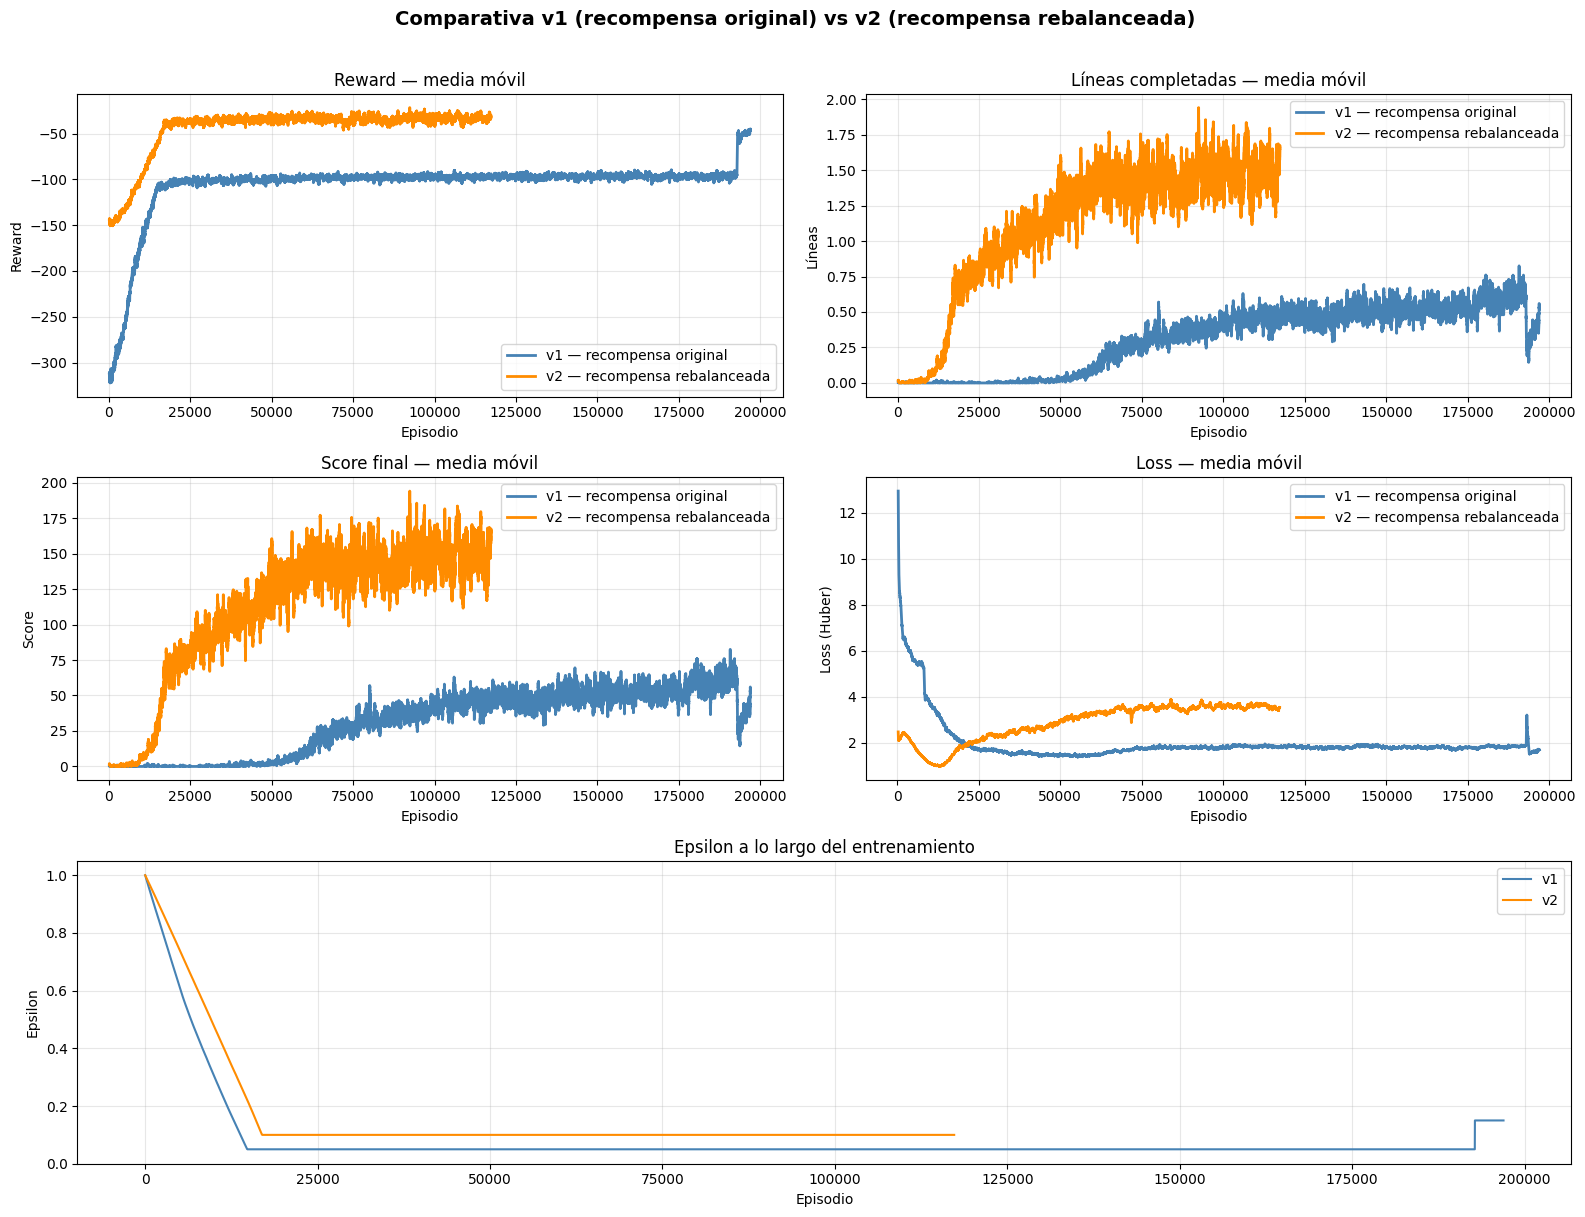

Guardada en 'comparativa_v1_v2.png'


In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

df_v1 = pd.read_csv("logs_dueling.csv")
df_v2 = pd.read_csv("logs_v2.csv")

print(f"v1 — episodios: {len(df_v1)}")
print(f"v2 — episodios: {len(df_v2)}")

VENTANA = 200  # ventana más grande porque tenemos muchos episodios

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(3, 2, figure=fig)

# --- 1. Reward media móvil ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(df_v1["episodio"], df_v1["reward_total"].rolling(VENTANA).mean(),
         color="steelblue", linewidth=2, label="v1 — recompensa original")
ax1.plot(df_v2["episodio"], df_v2["reward_total"].rolling(VENTANA).mean(),
         color="darkorange", linewidth=2, label="v2 — recompensa rebalanceada")
ax1.set_title("Reward — media móvil")
ax1.set_xlabel("Episodio")
ax1.set_ylabel("Reward")
ax1.legend()
ax1.grid(alpha=0.3)

# --- 2. Líneas media móvil ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(df_v1["episodio"], df_v1["lineas_episodio"].rolling(VENTANA).mean(),
         color="steelblue", linewidth=2, label="v1 — recompensa original")
ax2.plot(df_v2["episodio"], df_v2["lineas_episodio"].rolling(VENTANA).mean(),
         color="darkorange", linewidth=2, label="v2 — recompensa rebalanceada")
ax2.set_title("Líneas completadas — media móvil")
ax2.set_xlabel("Episodio")
ax2.set_ylabel("Líneas")
ax2.legend()
ax2.grid(alpha=0.3)

# --- 3. Score media móvil ---
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(df_v1["episodio"], df_v1["score_final"].rolling(VENTANA).mean(),
         color="steelblue", linewidth=2, label="v1 — recompensa original")
ax3.plot(df_v2["episodio"], df_v2["score_final"].rolling(VENTANA).mean(),
         color="darkorange", linewidth=2, label="v2 — recompensa rebalanceada")
ax3.set_title("Score final — media móvil")
ax3.set_xlabel("Episodio")
ax3.set_ylabel("Score")
ax3.legend()
ax3.grid(alpha=0.3)

# --- 4. Loss media móvil ---
ax4 = fig.add_subplot(gs[1, 1])
lv1 = df_v1[df_v1["loss_media"] > 0]
lv2 = df_v2[df_v2["loss_media"] > 0]
ax4.plot(lv1["episodio"], lv1["loss_media"].rolling(VENTANA).mean(),
         color="steelblue", linewidth=2, label="v1 — recompensa original")
ax4.plot(lv2["episodio"], lv2["loss_media"].rolling(VENTANA).mean(),
         color="darkorange", linewidth=2, label="v2 — recompensa rebalanceada")
ax4.set_title("Loss — media móvil")
ax4.set_xlabel("Episodio")
ax4.set_ylabel("Loss (Huber)")
ax4.legend()
ax4.grid(alpha=0.3)

# --- 5. Epsilon ---
ax5 = fig.add_subplot(gs[2, :])
ax5.plot(df_v1["episodio"], df_v1["epsilon"],
         color="steelblue", linewidth=1.5, label="v1")
ax5.plot(df_v2["episodio"], df_v2["epsilon"],
         color="darkorange", linewidth=1.5, label="v2")
ax5.set_title("Epsilon a lo largo del entrenamiento")
ax5.set_xlabel("Episodio")
ax5.set_ylabel("Epsilon")
ax5.set_ylim(0, 1.05)
ax5.legend()
ax5.grid(alpha=0.3)

plt.suptitle("Comparativa v1 (recompensa original) vs v2 (recompensa rebalanceada)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("comparativa_v1_v2.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardada en 'comparativa_v1_v2.png'")

**Comparativa v1 vs v2**

Los resultados muestran una mejora clara al rebalancear la función de recompensa. La v2 aprende más rápido y alcanza una media de líneas de ~1.5 frente al ~0.5 de la v1, y un score medio de ~150 frente a ~50. Esto sugiere que la v1 tenía las penalizaciones demasiado agresivas, lo que impedía que el agente aprendiera a priorizar limpiar líneas.

Dicho esto, los resultados absolutos siguen siendo modestos. una media de 1.5 líneas por episodio indica que el agente ha aprendido una política básica pero está lejos de jugar bien al Tetris. La mejora es real y cuantificable, pero el problema sigue siendo difícil y requeriría más tiempo de entrenamiento o ajustes adicionales para obtener resultados verdaderamente competitivos.